In [ ]:
!pip install deap seaborn
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from deap import base, creator, tools, algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


In [ ]:
# 24-Hour Passenger Demand Dataset (Busy Urban Route)

avg_passengers_per_hour = [
    200, 180, 150, 120, 100, 150,
    600, 900, 1200, 1000, 900, 800,
    700, 650, 600, 800, 1000, 1400,
    1600, 1000, 700, 500, 400, 300
]

assert len(avg_passengers_per_hour) == 24

# Convert to 12-hour format
time_intervals_12hr = []
for h in range(24):
    hour_12 = h % 12
    hour_12 = 12 if hour_12 == 0 else hour_12
    period = "AM" if h < 12 else "PM"
    time_intervals_12hr.append(f"{hour_12:02d}:00 – {hour_12:02d}:59 {period}")

demand_df = pd.DataFrame({
    "Hour": range(1, 25),
    "Time Interval": time_intervals_12hr,
    "Average Passenger Demand": avg_passengers_per_hour
})

print("\nPassenger Demand Dataset\n")
display(demand_df)


Passenger Demand Dataset



,Hour,Time Interval,Average Passenger Demand
0,1,12:00 – 12:59 AM,200
1,2,01:00 – 01:59 AM,180
2,3,02:00 – 02:59 AM,150
3,4,03:00 – 03:59 AM,120
4,5,04:00 – 04:59 AM,100
5,6,05:00 – 05:59 AM,150
6,7,06:00 – 06:59 AM,600
7,8,07:00 – 07:59 AM,900
8,9,08:00 – 08:59 AM,1200
9,10,09:00 – 09:59 AM,1000


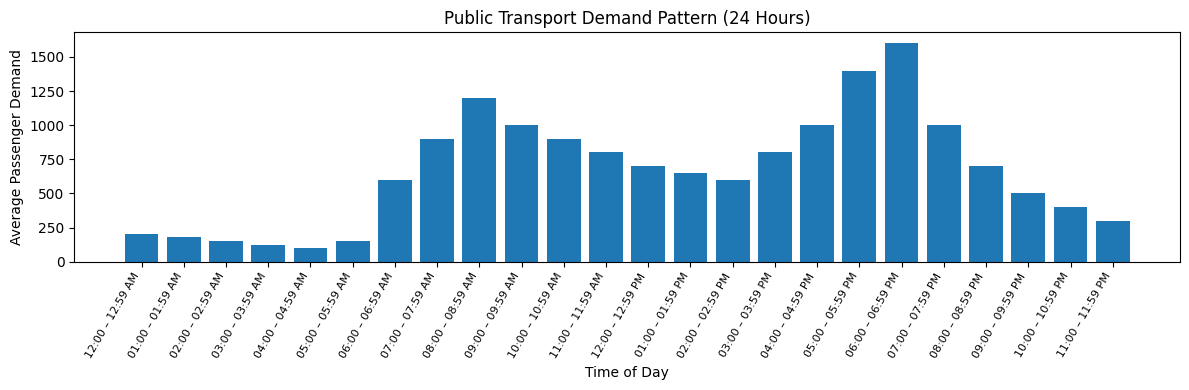

In [ ]:
plt.figure(figsize=(12,4))
plt.bar(demand_df["Time Interval"], demand_df["Average Passenger Demand"])

plt.xticks(rotation=60, ha='right', fontsize=8)
plt.xlabel("Time of Day")
plt.ylabel("Average Passenger Demand")
plt.title("Public Transport Demand Pattern (24 Hours)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

demand_array = np.array(avg_passengers_per_hour)
hours = np.arange(24).reshape(-1, 1)

model = LinearRegression()
model.fit(hours, demand_array)

predicted_demand = model.predict(hours).astype(int)

print("Predicted Passenger Demand:")
print(predicted_demand)

Predicted Passenger Demand:
[365 391 417 443 469 495 521 547 573 599 625 651 677 703 729 755 781 807
 833 859 885 911 937 963]


In [ ]:
passenger_arrivals = []

for hour, hourly_avg in enumerate(predicted_demand):
    base = hourly_avg // 60
    remainder = hourly_avg % 60

    for minute in range(60):
        count = base + (1 if minute < remainder else 0)
        passenger_arrivals.extend([hour * 60 + minute] * count)

passenger_arrivals = np.array(passenger_arrivals)

print("Total Simulated Passenger Arrivals:", len(passenger_arrivals))

Total Simulated Passenger Arrivals: 15936


In [ ]:
baseline_schedule = np.arange(0, 1440, 15)

def minutes_to_time(minute):
    hour = minute // 60
    minute_part = minute % 60
    period = "AM" if hour < 12 else "PM"
    hour_12 = hour % 12
    hour_12 = 12 if hour_12 == 0 else hour_12
    return f"{hour_12:02d}:{minute_part:02d} {period}"

baseline_df = pd.DataFrame({
    "Bus No": np.arange(1, len(baseline_schedule) + 1),
    "Departure Time": [minutes_to_time(m) for m in baseline_schedule],
    "Interval": ["Every 15 min"] * len(baseline_schedule)
})

print("\nTraditional Bus Schedule\n")
display(baseline_df.head(12))


Traditional Bus Schedule



,Bus No,Departure Time,Interval
0,1,12:00 AM,Every 15 min
1,2,12:15 AM,Every 15 min
2,3,12:30 AM,Every 15 min
3,4,12:45 AM,Every 15 min
4,5,01:00 AM,Every 15 min
5,6,01:15 AM,Every 15 min
6,7,01:30 AM,Every 15 min
7,8,01:45 AM,Every 15 min
8,9,02:00 AM,Every 15 min
9,10,02:15 AM,Every 15 min


In [ ]:
def average_wait_time(schedule):
    waits = []
    for p in passenger_arrivals:
        future = schedule[schedule >= p]
        if len(future) > 0:
            waits.append(future[0] - p)
    return np.mean(waits)

baseline_avg_wait = average_wait_time(baseline_schedule)

baseline_summary = pd.DataFrame({
    "Metric": [
        "Average Passenger Waiting Time (minutes)",
        "Total Buses Operated"
    ],
    "Baseline Result": [
        round(baseline_avg_wait, 2),
        len(baseline_schedule)
    ]
})

display(baseline_summary)

,Metric,Baseline Result
0,Average Passenger Waiting Time (minutes),7.01
1,Total Buses Operated,96.00


In [ ]:
from deap import base as deap_base

# Create fitness and individual safely
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", deap_base.Fitness, weights=(-1.0, -1.0))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMulti)

# Parameters
NUM_BUSES = 120
MIN_HEADWAY = 5
MAX_HEADWAY = 20

# Schedule creation
def create_schedule():
    time = 0
    schedule = []
    while time < 1440 and len(schedule) < NUM_BUSES:
        time += random.randint(MIN_HEADWAY, MAX_HEADWAY)
        if time < 1440:
            schedule.append(time)
    return schedule

# Use SAFE alias
toolbox = deap_base.Toolbox()

toolbox.register("individual", tools.initIterate, creator.Individual, create_schedule)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

In [ ]:
def evaluate(individual):
    schedule = np.array(sorted(individual))
    waits = []

    for p in passenger_arrivals:
        future = schedule[schedule >= p]
        if len(future) > 0:
            waits.append(future[0] - p)

    avg_wait = np.mean(waits) if len(waits) > 0 else 0
    return avg_wait, len(schedule)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

In [ ]:
population = toolbox.population(n=100)
GENERATIONS = 50

avg_wait_per_gen = []

for gen in range(GENERATIONS):
    population, _ = algorithms.eaMuPlusLambda(
        population,
        toolbox,
        mu=50,
        lambda_=100,
        cxpb=0.7,
        mutpb=0.3,
        ngen=1,
        verbose=False
    )

    avg_wait = np.mean([ind.fitness.values[0] for ind in population])
    avg_wait_per_gen.append(avg_wait)

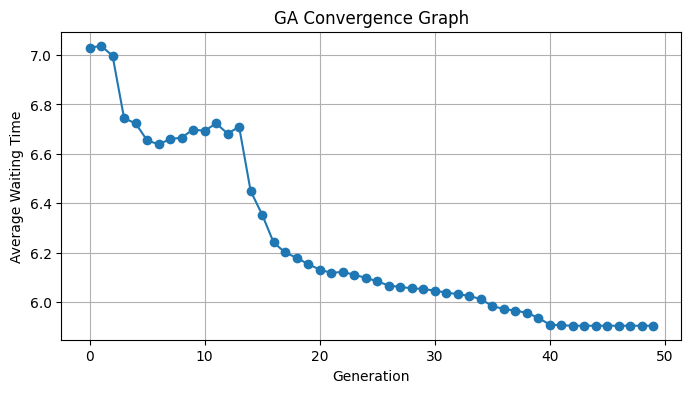

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(avg_wait_per_gen, marker='o')

plt.xlabel("Generation")
plt.ylabel("Average Waiting Time")
plt.title("GA Convergence Graph")

plt.grid(True)
plt.show()

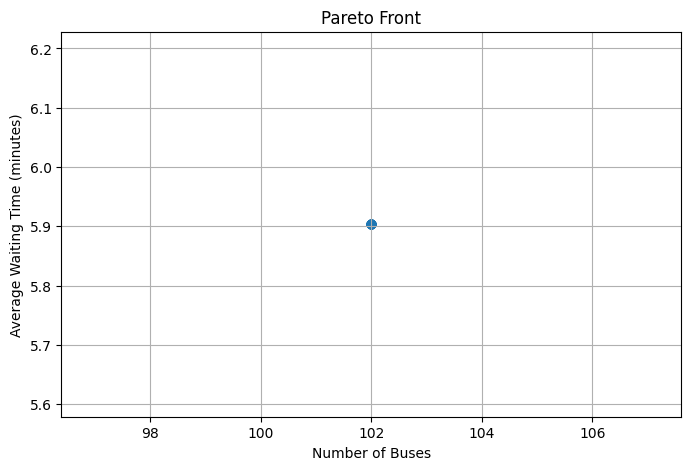

In [ ]:
# Pareto Front Visualization

waiting_times = [ind.fitness.values[0] for ind in population]
bus_counts = [ind.fitness.values[1] for ind in population]

plt.figure(figsize=(8,5))
plt.scatter(bus_counts, waiting_times)

plt.xlabel("Number of Buses")
plt.ylabel("Average Waiting Time (minutes)")
plt.title("Pareto Front")

plt.grid(True)
plt.show()

In [ ]:
# Best Solution Extraction

best_individual = min(population, key=lambda ind: ind.fitness.values[0])

optimized_schedule = np.array(sorted(best_individual))

optimized_avg_wait = evaluate(best_individual)[0]

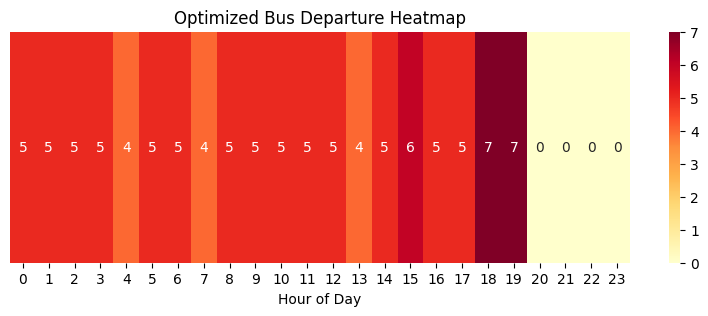

In [ ]:
hour_bins = optimized_schedule // 60

heatmap_data = pd.Series(hour_bins).value_counts().sort_index()
heatmap_data = heatmap_data.reindex(range(24), fill_value=0)

plt.figure(figsize=(10,3))
sns.heatmap([heatmap_data.values], cmap="YlOrRd", annot=True, fmt="d")

plt.xlabel("Hour of Day")
plt.title("Optimized Bus Departure Heatmap")

plt.yticks([])
plt.show()

In [ ]:
optimized_avg_wait = evaluate(best_individual)[0]
optimized_bus_count = len(best_individual)

comparison_df = pd.DataFrame({
    "Metric": [
        "Average Waiting Time (minutes)",
        "Total Buses Used"
    ],
    "Baseline": [
        round(baseline_avg_wait, 2),
        len(baseline_schedule)
    ],
    "Optimized (GA + ML)": [
        round(optimized_avg_wait, 2),
        optimized_bus_count
    ]
})

print("\nBaseline vs Optimized Comparison\n")
display(comparison_df)


Baseline vs Optimized Comparison



,Metric,Baseline,Optimized (GA + ML)
0,Average Waiting Time (minutes),7.01,5.9
1,Total Buses Used,96.00,102.0


In [ ]:
# Festival Scenario (5x Demand Increase)

festival_demand = [x * 5 for x in avg_passengers_per_hour]

# Use SAME time format as original
festival_df = pd.DataFrame({
    "Hour": range(1, 25),
    "Time Interval": demand_df["Time Interval"],  # reuse same intervals
    "Festival Passenger Demand": festival_demand
})

print("\nFestival Public Transport Demand (5x Increased)\n")
display(festival_df)


Festival Public Transport Demand (5x Increased)



,Hour,Time Interval,Festival Passenger Demand
0,1,12:00 – 12:59 AM,1000
1,2,01:00 – 01:59 AM,900
2,3,02:00 – 02:59 AM,750
3,4,03:00 – 03:59 AM,600
4,5,04:00 – 04:59 AM,500
5,6,05:00 – 05:59 AM,750
6,7,06:00 – 06:59 AM,3000
7,8,07:00 – 07:59 AM,4500
8,9,08:00 – 08:59 AM,6000
9,10,09:00 – 09:59 AM,5000


In [ ]:
# ML Prediction for Festival Demand

from sklearn.linear_model import LinearRegression

festival_array = np.array(festival_demand)
hours = np.arange(24).reshape(-1, 1)

model_festival = LinearRegression()
model_festival.fit(hours, festival_array)

predicted_festival_demand = model_festival.predict(hours).astype(int)

print("Predicted Festival Demand:")
print(predicted_festival_demand)

Predicted Festival Demand:
[1827 1957 2087 2217 2347 2477 2607 2737 2867 2997 3127 3257 3387 3518
 3648 3778 3908 4038 4168 4298 4428 4558 4688 4818]


In [ ]:
# Festival Passenger Simulation

festival_arrivals = []

for hour, hourly_avg in enumerate(predicted_festival_demand):
    base = hourly_avg // 60
    remainder = hourly_avg % 60

    for minute in range(60):
        count = base + (1 if minute < remainder else 0)
        festival_arrivals.extend([hour * 60 + minute] * count)

festival_arrivals = np.array(festival_arrivals)

print("Total Festival Passenger Arrivals:", len(festival_arrivals))

Total Festival Passenger Arrivals: 79739


In [ ]:
# Evaluation function for festival scenario

def evaluate_festival(individual):
    schedule = np.array(sorted(individual))
    waits = []

    for p in festival_arrivals:
        future = schedule[schedule >= p]
        if len(future) > 0:
            waits.append(future[0] - p)

    avg_wait = np.mean(waits) if len(waits) > 0 else 0
    return avg_wait, len(schedule)

In [ ]:
# Backup original evaluation
original_evaluate = toolbox.evaluate

# evaluate with festival version
toolbox.unregister("evaluate")
toolbox.register("evaluate", evaluate_festival)

population_festival = toolbox.population(n=100)

for gen in range(GENERATIONS):
    population_festival, _ = algorithms.eaMuPlusLambda(
        population_festival,
        toolbox,
        mu=50,
        lambda_=100,
        cxpb=0.7,
        mutpb=0.3,
        ngen=1,
        verbose=False
    )

# Restore original evaluation
toolbox.unregister("evaluate")
toolbox.register("evaluate", original_evaluate)

In [ ]:
#  best festival solution

best_festival = min(population_festival, key=lambda ind: evaluate_festival(ind)[0])

festival_avg_wait = evaluate_festival(best_festival)[0]
festival_bus_count = len(best_festival)

print("Festival Avg Waiting Time:", round(festival_avg_wait, 2))
print("Festival Bus Count:", festival_bus_count)

Festival Avg Waiting Time: 5.88
Festival Bus Count: 120


In [ ]:
# Final Comparison Table

festival_comparison = pd.DataFrame({
    "Scenario": ["Normal", "Festival (5x Demand)"],
    "Average Waiting Time (minutes)": [
        round(optimized_avg_wait, 2),
        round(festival_avg_wait, 2)
    ],
    "Total Buses Used": [
        optimized_bus_count,
        festival_bus_count
    ]
})

print("\nNormal vs Festival Scenario Comparison\n")
display(festival_comparison)


Normal vs Festival Scenario Comparison



,Scenario,Average Waiting Time (minutes),Total Buses Used
0,Normal,5.90,102
1,Festival (5x Demand),5.88,120
